In [2]:
import os
import pandas as pd

# Tự động tìm đường dẫn chứa train.csv
train_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    if 'train.csv' in filenames:
        train_path = os.path.join(dirname, 'train.csv')
        input_dir = dirname
        break

print(f"Đã tìm thấy thư mục dữ liệu tại: {input_dir}")
print(f"Đường dẫn file train: {train_path}")

# Đọc dữ liệu
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(os.path.join(input_dir, 'test.csv'))

print(f"Kích thước tập train: {train_df.shape}")
print(f"Kích thước tập test: {test_df.shape}")

Đã tìm thấy thư mục dữ liệu tại: /kaggle/input/competitions/house-prices-advanced-regression-techniques
Đường dẫn file train: /kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
Kích thước tập train: (1460, 81)
Kích thước tập test: (1459, 80)


In [3]:
import pandas as pd
import numpy as np

# 1. Kiểm tra các kiểu dữ liệu trong tập train
print("--- SỐ LƯỢNG CÁC KIỂU DỮ LIỆU ---")
print(train_df.dtypes.value_counts())

# 2. Thống kê các cột có giá trị bị thiếu (Missing Values)
missing_values = train_df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("\n--- CÁC CỘT CÓ GIÁ TRỊ KHUYẾT THIẾU (TOP 10) ---")
print(missing_values.head(10))

# 3. Xem thống kê nhanh biến mục tiêu SalePrice (Giá nhà)
print("\n--- THỐNG KÊ BIẾN MỤC TIÊU (SalePrice) ---")
print(train_df['SalePrice'].describe())

--- SỐ LƯỢNG CÁC KIỂU DỮ LIỆU ---
object     43
int64      35
float64     3
Name: count, dtype: int64

--- CÁC CỘT CÓ GIÁ TRỊ KHUYẾT THIẾU (TOP 10) ---
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
dtype: int64

--- THỐNG KÊ BIẾN MỤC TIÊU (SalePrice) ---
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [4]:
import pandas as pd
import numpy as np

# Kết hợp train và test lại để xử lý tiền xử lý đồng bộ (trừ cột SalePrice)
y_train = train_df['SalePrice']
train_features = train_df.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
test_features = test_df.drop(['Id'], axis=1, errors='ignore')

# Gộp lại thành một dataframe tổng để xử lý missing values
all_df = pd.concat([train_features, test_features], axis=0).reset_index(drop=True)

# 1. Xử lý các cột mà giá trị thiếu có nghĩa là "Không có" (None)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']
for col in none_cols:
    if col in all_df.columns:
        all_df[col] = all_df[col].fillna('None')

# 2. Xử lý các cột số bị thiếu bằng giá trị 0 hoặc trung vị (median)
zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea']
for col in zero_cols:
    if col in all_df.columns:
        all_df[col] = all_df[col].fillna(0)

# Riêng LotFrontage (mặt tiền nhà) điền bằng giá trị trung median của khu vực
all_df['LotFrontage'] = all_df['LotFrontage'].fillna(all_df['LotFrontage'].median())

# Các cột chữ còn lại (nếu có) điền bằng giá trị phổ biến nhất (mode)
for col in all_df.select_dtypes(include=['object']).columns:
    all_df[col] = all_df[col].fillna(all_df['MODE'] if 'MODE' in all_df else all_df[col].mode()[0])

# Các cột số còn lại điền bằng 0
all_df = all_df.fillna(0)

print(f"Kích thước sau khi xử lý missing values: {all_df.shape}")

Kích thước sau khi xử lý missing values: (2919, 79)


In [5]:
from sklearn.preprocessing import LabelEncoder

# 1. Mã hóa các biến phân loại (object) sang dạng số
for col in all_df.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    # Chuyển thành chuỗi để tránh lỗi NaN/chưa xử lý hết
    all_df[col] = le.fit_transform(all_df[col].astype(str))

# 2. Tách lại thành tập train và test dựa vào kích thước ban đầu (1460 dòng đầu là train)
X_train = all_df.iloc[:1460, :]
X_test = all_df.iloc[1460:, :]

print(f"Kích thước X_train: {X_train.shape}")
print(f"Kích thước X_test: {X_test.shape}")
print(f"Kích thước y_train: {y_train.shape}")

Kích thước X_train: (1460, 79)
Kích thước X_test: (1459, 79)
Kích thước y_train: (1460,)


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Khởi tạo mô hình Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Huấn luyện mô hình trên tập train
model.fit(X_train, y_train)

# 3. Dự đoán lại trên tập train để kiểm tra độ sai số (RMSE)
y_train_pred = model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
print(f"RMSE trên tập train: {train_rmse:.4f}")

# 4. Dự đoán trên tập test (X_test)
test_predictions = model.predict(X_test)

# 5. Tạo file submission để nộp bài lên Kaggle
submission = pd.DataFrame({
    'Id': test_df['Id'],
    'SalePrice': test_predictions
})

# Lưu ra file CSV
submission.to_csv('submission.csv', index=False)
print("Đã tạo thành công file submission.csv!")

RMSE trên tập train: 11109.5487
Đã tạo thành công file submission.csv!


Đã vẽ và lưu thành công biểu đồ nghiệm thu: 'model_evaluation_report.png'!


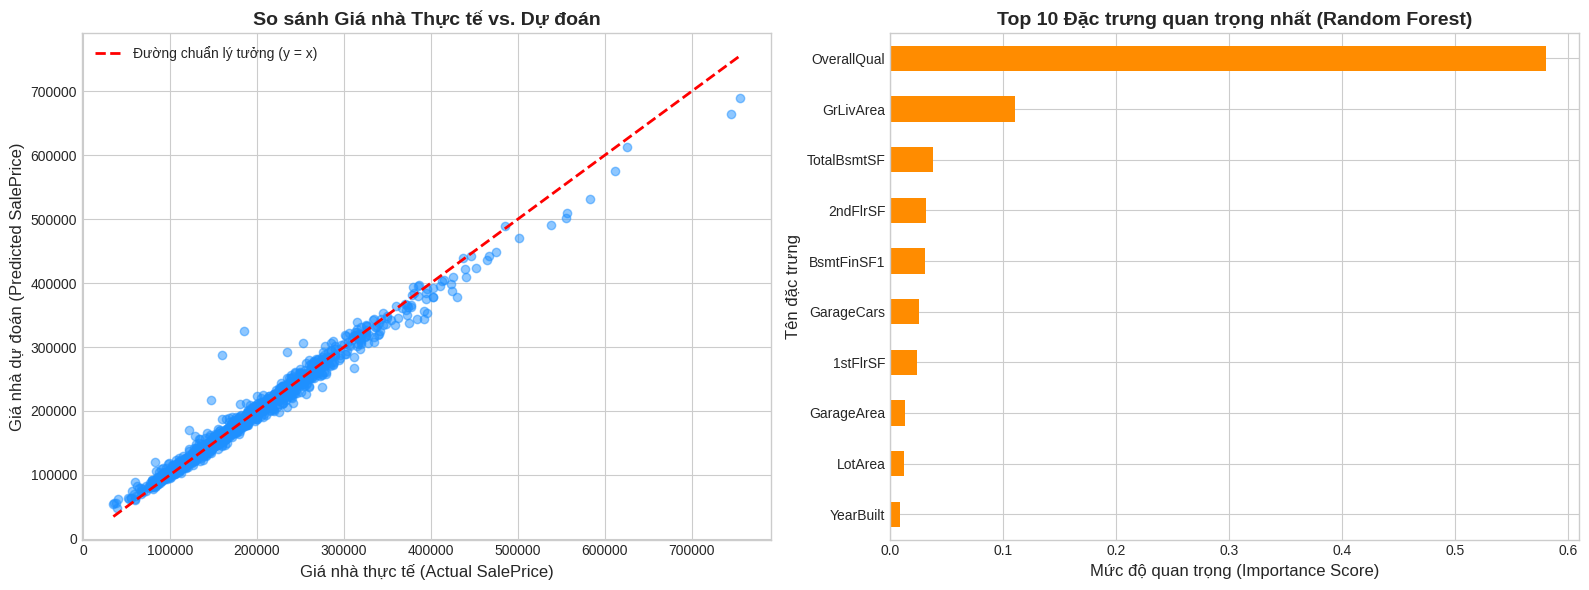

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình giao diện biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- BIỂU ĐỒ 1: SO SÁNH GIÁ THỰC TẾ VÀ GIÁ DỰ ĐOÁN (TRAIN SET) ---
y_train_pred = model.predict(X_train)
axes[0].scatter(y_train, y_train_pred, alpha=0.5, color='dodgerblue')
axes[0].plot(
    [y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
    'r--', lw=2, label='Đường chuẩn lý tưởng (y = x)'
)
axes[0].set_title('So sánh Giá nhà Thực tế vs. Dự đoán', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Giá nhà thực tế (Actual SalePrice)', fontsize=12)
axes[0].set_ylabel('Giá nhà dự đoán (Predicted SalePrice)', fontsize=12)
axes[0].legend()

# --- BIỂU ĐỒ 2: TOP 10 ĐẶC TRƯNG QUAN TRỌNG NHẤT (FEATURE IMPORTANCE) ---
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
top_10_features = feature_importances.nlargest(10)

top_10_features.plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 Đặc trưng quan trọng nhất (Random Forest)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Mức độ quan trọng (Importance Score)', fontsize=12)
axes[1].set_ylabel('Tên đặc trưng', fontsize=12)
axes[1].invert_yaxis() # Đảo chiều để đặc trưng quan trọng nhất lên trên cùng

plt.tight_layout()

# Lưu lại hình ảnh nghiệm thu trực tiếp vào thư mục làm việc
plt.savefig('model_evaluation_report.png', dpi=300)
print("Đã vẽ và lưu thành công biểu đồ nghiệm thu: 'model_evaluation_report.png'!")

# Hiển thị biểu đồ ngay trực tiếp trong Notebook
plt.show()